# Loss Landscape

In [ ]:
import os
import sys
from pathlib import Path
# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from src.utils.io import load_path_config
from src.data_processing.loading import load_single_csv
from src.training.loss_functions import custom_loss_10
from src.training.loss_functions import custom_loss_11

In [16]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

test_data = load_single_csv(
    paths_config['processed_paths']['returns_test'],
    index_dt=True
)

In [45]:
returns_window = test_data[-60:].values
print(returns_window.shape)
returns_tensor = torch.tensor(returns_window, dtype=torch.float32)
T, N = returns_tensor.shape  # T = 60, N = 50

(60, 50)


In [46]:
n_points = 100
w_i_vals = np.linspace(0, 1, n_points)
w_j_vals = np.linspace(0, 1, n_points)

loss_grid = np.full((n_points, n_points), np.nan)

In [47]:
def evaluate_loss(weights_1d, returns_2d, cvar_lambda, risk_p_lambda):
    # weights_1d: (N,)
    # returns_2d: (T, N)
    w_batch = weights_1d.unsqueeze(0)          # (1, N)
    ret_batch = returns_2d.unsqueeze(0)         # (1, T, N)
    pf = (w_batch * ret_batch).sum(dim=-1)      # (1, T)
    loss = custom_loss_11(w_batch, ret_batch, pf, cvar_lambda, risk_p_lambda)
    return loss.item()

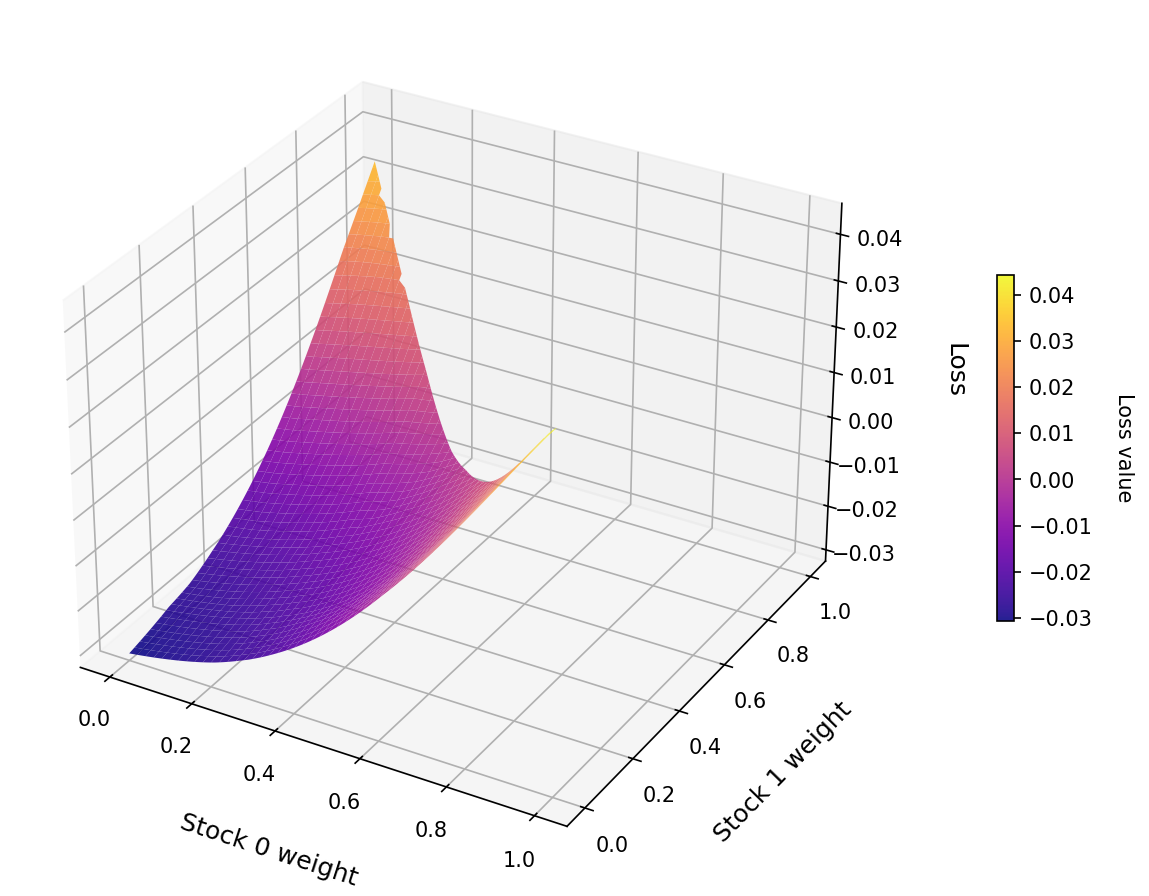

In [48]:
# choose two assets
i, j = 0, 1

# fixed hparams
cvar_lambda = 0.001
risk_p_lambda = 0.1

for idx_i, wi in enumerate(w_i_vals):
    for idx_j, wj in enumerate(w_j_vals):
        if wi + wj > 1:
            continue
        # build full weight vector
        w = np.zeros(N)
        w[i] = wi
        w[j] = wj
        remaining = 1 - wi - wj
        others = [k for k in range(N) if k not in (i, j)]
        w[others] = remaining / len(others)
        
        w_tensor = torch.tensor(w, dtype=torch.float32)
        loss = evaluate_loss(w_tensor, returns_tensor, cvar_lambda, risk_p_lambda)
        loss_grid[idx_i, idx_j] = loss

# Plot
W_i, W_j = np.meshgrid(w_i_vals, w_j_vals)

fig = plt.figure(figsize=(8, 8), dpi=150)   # larger figure
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(W_i, W_j, loss_grid, cmap='plasma', edgecolor='none', alpha=0.9)

# Labels with more padding to avoid cut-off
ax.set_xlabel(f'Stock {i} weight', fontsize=12, labelpad=15)
ax.set_ylabel(f'Stock {j} weight', fontsize=12, labelpad=15)
ax.set_zlabel('Loss', fontsize=12, labelpad=15, rotation=270)

# Ticks
ax.tick_params(axis='both', labelsize=10)

# Colorbar – create first, then set label with rotation and padding
cbar = fig.colorbar(surf, ax=ax, shrink=0.3, aspect=20, pad=0.1)
cbar.set_label('Loss value', rotation=270, labelpad=20, fontsize=10)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

# plt.savefig('loss_landscape.png', dpi=300, bbox_inches='tight')